# CompIntelLab2026 Lab2: Reinforcement Learning: Effectiveness and efficiency of intelligent agents (RL-based and non-RL-based) acting in RL environments

---



## [Szwabe]: Your task: Extend the policy code by applying BO to optimize a PID-based agent operating in an RL environment.

**The Context:**
Deep Reinforcement Learning (like DQN) is powerful but incredibly sample-inefficient. It assumes no prior knowledge of the environment and must learn entirely by trial and error, adjusting thousands of neural network weights via backpropagation.

**The Challenge:**
We can bypass this massive computational cost by injecting a **structural heuristic** (domain knowledge). We know CartPole can be solved using a classical PID controller. This collapses our search space from thousands of neural weights to just **3 continuous parameters (P, I, D)**.

Your task is to implement **Bayesian Optimization (via `scikit-optimize`)** to navigate this 3-variable search space and find the optimal PID parameters in a fraction of the time it takes the DQN to train.

We inject educational domain knowledge: a classical PID controller with explicit Proportional, Integral, and Derivative components. We intentionally handicap this agent to rely strictly on the pole angle (`observation[2]`), compared to the DQN which maps the entire 4-variable state space.

**You must implement two variants:**
1. **Variant A (Fast & Noisy):** Evaluate each parameter set over just 10 episodes.
2. **Variant B (Slow & Smooth):** Evaluate each parameter set over 100 episodes to reduce stochastic variance and provide the Gaussian Process with a smoother objective landscape.

In [ ]:
!pip install scikit-optimize gymnasium torch matplotlib numpy imageio imageio-ffmpeg

### 1. Imports and Device Setup

In [ ]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import time
import numpy as np

# Patch for scikit-optimize compatibility with modern NumPy
np.int = int
np.float = float
np.bool = bool

import imageio
import base64

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_objective, plot_evaluations

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

device = torch.device('cpu')
print(f'Using device: {device}')

# Global tracking variables for the final training-efficiency comparison
metrics = {
    'dqn_time': 0.0,
    'dqn_steps': 0,
    'bo10_time': 0.0,
    'bo10_steps': 0,
    'bo100_time': 0.0,
    'bo100_steps': 0
}

Using device: cpu


### 2. Common Evaluation & Video Utilities
To ensure a perfectly identical and fair evaluation, all policies will be run through the exact same evaluation functions.

In [ ]:
def evaluate_policy(act_func, reset_func=None, num_eval_episodes=1000):
    env = gym.make('CartPole-v1')
    eval_durations = []
    for ep in range(num_eval_episodes):
        state, info = env.reset()
        if reset_func:
            reset_func()
        duration = 0
        done = False
        while not done:
            action = act_func(state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            duration += 1
        eval_durations.append(duration)
    env.close()

    avg_score = sum(eval_durations) / num_eval_episodes
    print(f"\nAverage Score: {avg_score} / 500.0")

    if avg_score == 500.0:
        print("\n🏆 SUCCESS! 🏆")
    else:
        print("\n❌ Score too low. Keep working on your solution!")

    plt.figure(figsize=(12, 4))
    plt.plot(range(1, num_eval_episodes + 1), eval_durations, marker='.', linestyle='-', markersize=2, alpha=0.7)
    plt.title('Episode-Cumulative Testing Reward (Durations)')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.ylim(0, 520)
    plt.grid(True)
    plt.show()

    return avg_score

def render_policy_video(act_func, reset_func=None, video_path='video.mp4'):
    print(f"Rendering video to {video_path}...")
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    state, info = env.reset()
    if reset_func:
        reset_func()
    done = False
    frames = []

    while not done:
        frames.append(env.render())
        action = act_func(state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    env.close()
    imageio.mimsave(video_path, frames, fps=30)
    video = open(video_path, 'rb').read()
    encoded_video = base64.b64encode(video).decode('ascii')
    if is_ipython:
        display.display(display.HTML(f'''<video width="400" controls autoplay loop><source src="data:video/mp4;base64,{encoded_video}" type="video/mp4"></video>'''))
    print("Done rendering.")

---
## 3. DQN-based Policy
Here we implement the DQN architecture precisely from the CompIntel Lab 1 and run the same training loop.

In [ ]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

### Training the DQN

Complete


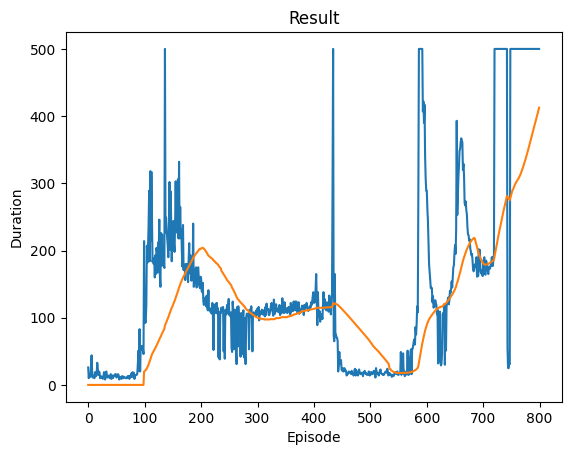

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
env = gym.make('CartPole-v1')

# DQN Hyperparameters
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000
TAU = 0.005
LR = 1e-4

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

# --- DQN TRAINING LOOP ---
start_time = time.time()
dqn_env_steps = 0
num_episodes = 800

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        dqn_env_steps += 1
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward)
        state = next_state
        optimize_model()

        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

# The wall-clock time measurement strictly covers only the training loop above,
# completely excluding any subsequent 1000-episode evaluation time.
metrics['dqn_time'] = time.time() - start_time
metrics['dqn_steps'] = dqn_env_steps

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()
env.close()

### Evaluate and Render DQN Policy
Using our shared evaluation utility.


Average Score: 500.0 / 500.0

🏆 SUCCESS! 🏆


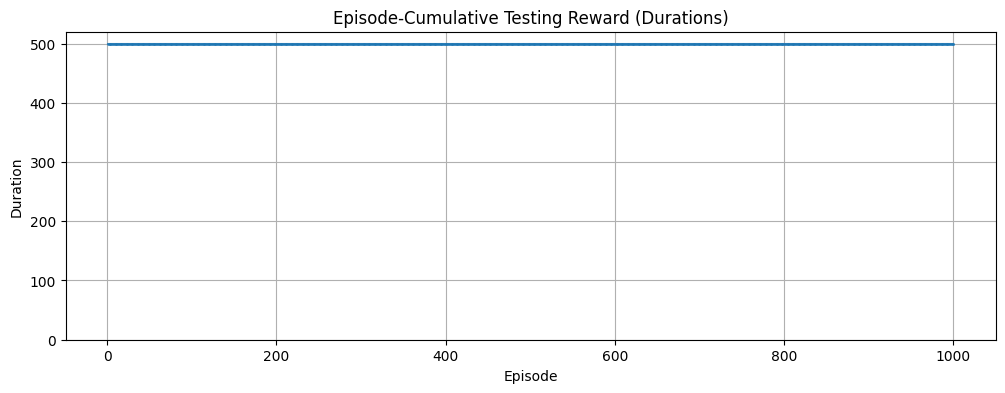

Rendering video to dqn_cartpole.mp4...


Done rendering.


In [ ]:
def dqn_act(state):
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return policy_net(state_tensor).max(1).indices.item()

dqn_avg_score = evaluate_policy(dqn_act, reset_func=None, num_eval_episodes=1000)
render_policy_video(dqn_act, reset_func=None, video_path='dqn_cartpole.mp4')

---
## 4. PID+BO-based Semi-Heuristic Policy
The code below defines the classical PID agent structure.

In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

class PIDAgent:
    def __init__(self, P, I, D):
        self.P = P
        self.I = I
        self.D = D
        self.integral = 0.0
        self.prev_error = 0.0

    def reset(self):
        self.integral = 0.0
        self.prev_error = 0.0

    def act(self, observation):
        error = observation[2]
        self.integral += error
        self.derivative = error - self.prev_error
        self.prev_error = error

        pid = self.P * error + self.I * self.integral + self.D * self.derivative
        action = sigmoid(pid)

        return np.round(action).astype(np.int32).item()

### TASK A: Variant A (10 episodes/eval)
**Your Job:**
1. Write an evaluation function that initializes a `PIDAgent` with `(P, I, D)` parameters, runs it for `10` episodes in `CartPole-v1`, and returns the average reward.
2. Remember to reset the agent (`agent.reset()`) at the start of every episode to clear integral windup!
3. Wrap the objective and run `gp_minimize` to find the best parameters.
4. Assign the best found parameters to `best_P_10`, `best_I_10`, `best_D_10`.

BO Complete


<Figure size 640x480 with 0 Axes>

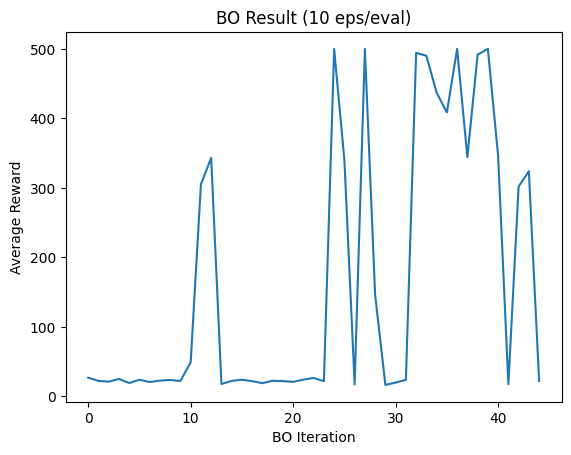

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

BO Optimization Complete. Time: 35.14s | Env Steps: 74130
Best found PID parameters: P=9.069360191029533, I=0.3037351791565003, D=94.50124795163016

Plotting Objective Landscape (10 eps/eval)...


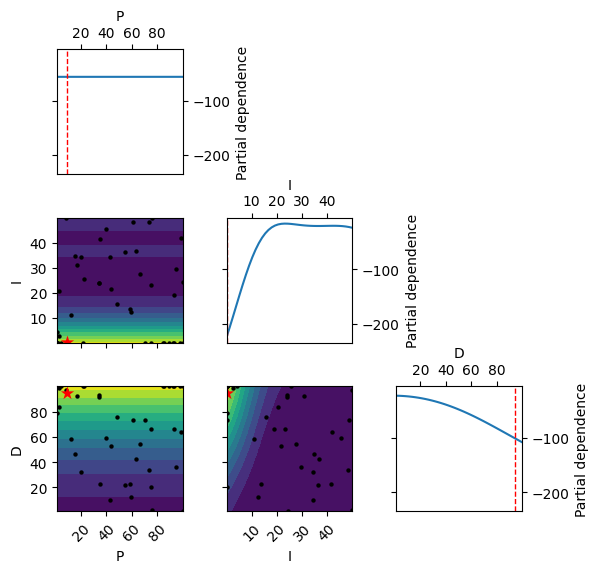


Plotting Evaluations (10 eps/eval)...


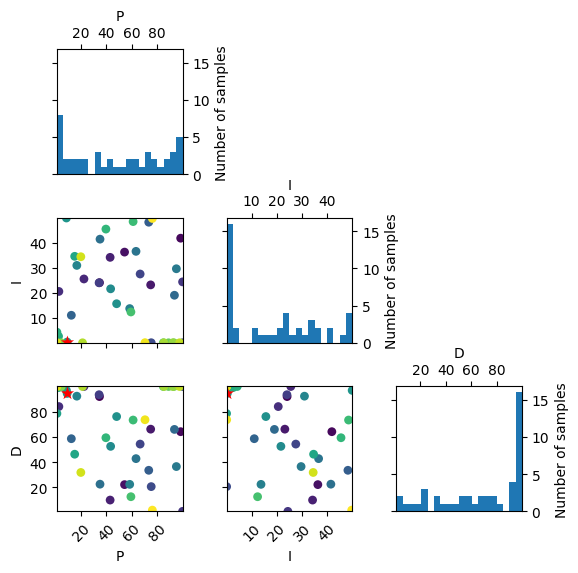

In [ ]:
bo10_env_steps = 0
bo10_scores = []
plt.ion()

def plot_bo10_scores(show_result=False):
    plt.figure(2)
    scores_t = torch.tensor(bo10_scores, dtype=torch.float)
    if show_result:
        plt.title('BO Result (10 eps/eval)')
    else:
        plt.clf()
        plt.title('BO Optimizing (10 eps/eval)...')
    plt.xlabel('BO Iteration')
    plt.ylabel('Average Reward')
    plt.plot(scores_t.numpy())
    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

# 1. Define the search space for scikit-optimize (Given to you)
space = [
    Real(1.0, 100.0, name='P'),
    Real(0.0, 50.0, name='I'),
    Real(1.0, 100.0, name='D')
]

# =====================================================================
# YOUR CODE HERE: Implement evaluate_agent_for_bo10(P, I, D, episodes=10)
# Track environment steps using the global bo10_env_steps variable
# Append your avg_score to bo10_scores and call plot_bo10_scores()
#
# [REPLACE THE ENTIRE evaluate_agent_for_bo10 FUNCTION BELOW WITH YOUR CODE]
# =====================================================================

def evaluate_agent_for_bo10(P, I, D, episodes=10):
  global bo10_env_steps
  env = gym.make('CartPole-v1')
  agent = PIDAgent(P, I, D)
  total_reward = 0.0

  for ep in range(episodes):
    state, info = env.reset()
    agent.reset() # reset składnika całkującego
    done = False
    ep_reward = 0

    while not done:
      action = agent.act(state)
      state, reward, terminated, truncated, info = env.step(action)
      done = terminated or truncated
      ep_reward += reward
      bo10_env_steps += 1

    total_reward += ep_reward

  env.close()
  avg_score = total_reward / episodes

  bo10_scores.append(avg_score)
  plot_bo10_scores()
  return avg_score

print("Starting BO PID Optimization (10 eps/eval)...")
start_time = time.time()

# =====================================================================
# YOUR CODE HERE:
# 1. Define the objective function wrapper using @use_named_args (remember skopt minimizes!)
# 2. Run gp_minimize (n_calls=45, n_initial_points=5) WITHOUT a hardcoded random_state
# 3. Extract best parameters into best_P_10, best_I_10, best_D_10
#
# [REPLACE EVERYTHING FROM HERE DOWN TO THE METRICS TRACKING WITH YOUR CODE]
# =====================================================================

@use_named_args(space)
def objective_10(P, I, D):
  avg_score = evaluate_agent_for_bo10(P, I, D, episodes=10)
  return -avg_score

res_10 = gp_minimize(
    func=objective_10,
    dimensions=space,
    n_calls=45,
    n_initial_points=5
)
best_P_10, best_I_10, best_D_10 = res_10.x


# Timing and Metrics (Do not change)
metrics['bo10_time'] = time.time() - start_time
metrics['bo10_steps'] = bo10_env_steps

print('BO Complete')
plot_bo10_scores(show_result=True)
plt.ioff()
plt.show()

best_pid_agent_10 = PIDAgent(P=best_P_10, I=best_I_10, D=best_D_10)
print(f"BO Optimization Complete. Time: {metrics['bo10_time']:.2f}s | Env Steps: {metrics['bo10_steps']}")
print(f"Best found PID parameters: P={best_P_10}, I={best_I_10}, D={best_D_10}")

try:
    print("\nPlotting Objective Landscape (10 eps/eval)...")
    _ = plot_objective(res_10)
    plt.show()
    print("\nPlotting Evaluations (10 eps/eval)...")
    _ = plot_evaluations(res_10)
    plt.show()
except NameError:
    print("Please define res_10 using gp_minimize to see the plots.")

Interpretacja (45 iteracji BO):

Ok. pierwsze 10 iteracji to niskie wyniki, czyli faza eksploracji. Przy 11-12 iteracji zaczęto kierować się w bardziej obiecujące obszary. Wiele skoków - prawdopodobnie w celu dalszej eksploracji w poszukiwaniu innych obszarów oprócz dotychczasowo znanych. Brak stabilności to bezpośrednia konsekwencja dużej wariancji estymatora średniej nagrody przy małej próbie.

Interpretacja (obraz 1):

**Przekątna** (partial dependence - dla danej wartości parametru X, GP oblicza predykcję dla wielu kombinacji pozostałych dwóch parametrów i zwraca ich średnią; np. krzywa P pokazuje dla P=20, jaki jest średni wynik po wszystkich możliwych parach (I, D))

**P** - krzywa płaska, zmiana P nie wpływa istotnie na uśredniony wynik, człon sam w sobie nie wpływa na jakość sterowania.

**I** - niskie I wyraźnie działa na plus, mała kumulacja błędu stabilizuje agenta, duże I prowadzi do destabilizacji, efekt jest bardzo łatwo dostrzegalny, bo widać go nawet po uśrednieniu różnych zestawów (P, D).

**D** - łagodny spadek wraz ze wzrostem D, silniejszy człon D poprawia wynik

**P vs I** - poziome paski, wynik zależy głównie od I (oś pionowa), a wzdłuż P prawie się nie zmienia, potwierdza się minimalny wpływ P

**P vs D** - im wyższe D tym lepszy wynik, P nie ma większego wpływu. Potwierdza obserwacje z przekątnej

**I vs D** - optimum w lewym górnym rogu, czyli przy niskiej wartości I i wysokim D + niskie I daje dość dobre wyniki nawet przy nieco niższym D

Interpretacja (obraz 2):

**Przekątna:** histogramy pokazują, ile razy optymalizator bayesowski próbował danej wartości parametru PID. W przypadku P, dużo w okolicach 10-20, czyli model preferował dość słabą reakcję na bieżący błąd, aby nie przeszacować w połączeniu z pozostałymi członami układu sterującego (I, D).

Dla członu całkującego, próbki koncentrowały się przy niskich wartościach - optymalizator ustalił, że zbyt duża wartość I skutkuje destabilizującym wpływem błędu historycznego na działanie agenta. Niewielkie I kompensuje odchylenia kąta w danym momencie.

W przypadku D, próbki pojawiły się w dużej mierze przy najwyższych wartościach. To bardzo silna reakcja na tempo zmian kąta. Człon może działać jak hamulec, reagując odpowiednio na ewentualne silne wahania kąta.

Optymalizator nie przeszukał przestrzeni możliwych wartości parametrów w sposób równomierny, pomimo losowych kilku próbek - następnie znalazł, w których miejscach regulator PID działa najlepiej i kontynuował optymalizację w tych rejonach. Zawężenie obszaru poszukiwań nie jest niczym złym - to pokazuje, że optymalizator bayesowski prowadził poszukiwania skutecznie i nie marnował obliczeń na mało obiecujące warianty.

**P vs I** - kropki rozproszone, bez wyraźnego skupiska. Dobre wyniki pojawiają  się obok słabych wyników (żółte-niebieskie). Przy 10 epizodach nie udało się znaleźć konkretnej zależności między P a I.

**P vs D** - lekko widoczne skupienie żółtych i zielonych kropek w lewym górnym rogu, blisko optimum. Czyli optymalizator widzi w tym regionie potencjał na rozwiązanie optymalne. Za mało epizodów, aby wyraźnie zaznaczyć, gdzie się skupić, aby szukać.

**I vs D** - najbardziej rozproszony, brak jakiegokolwiek wyraźnego wzorca. Przy 10 epizodach nie udało się wychwycić konkretnej zależności między I a D.


Average Score: 500.0 / 500.0

🏆 SUCCESS! 🏆


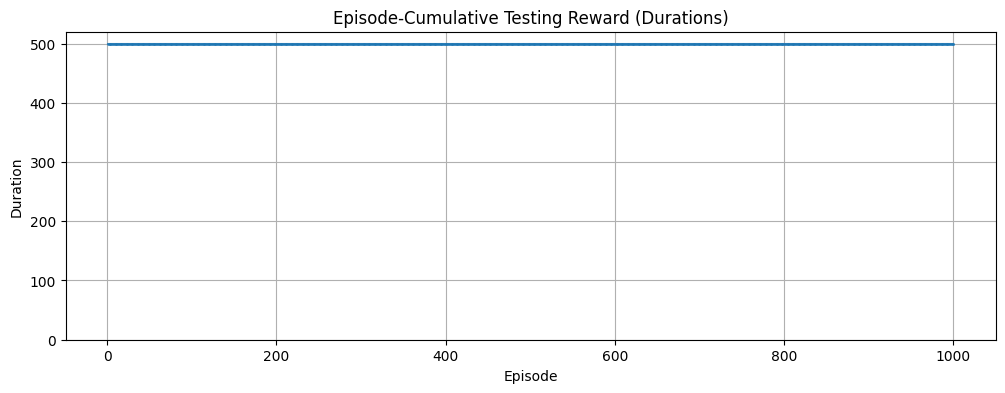

Rendering video to pid_cartpole_10.mp4...


Done rendering.


In [ ]:
def pid_act_10(state):
    return best_pid_agent_10.act(state)

pid10_avg_score = evaluate_policy(pid_act_10, reset_func=best_pid_agent_10.reset, num_eval_episodes=1000)
render_policy_video(pid_act_10, reset_func=best_pid_agent_10.reset, video_path='pid_cartpole_10.mp4')

### TASK B: Variant B (100 episodes/eval - Smoother Objective)

Because `CartPole-v1` is stochastic, evaluating a set of parameters over just 10 episodes provides a very noisy estimate of its true expected reward.

**Your Job:**
Copy your logic from Variant A below, but increase the evaluation episodes to `100`. Notice how the `plot_objective` landscape changes. By relying on the *Law of Large Numbers*, we drastically reduce the statistical variance, providing the Gaussian Process with a much cleaner landscape to model.

BO Complete


<Figure size 640x480 with 0 Axes>

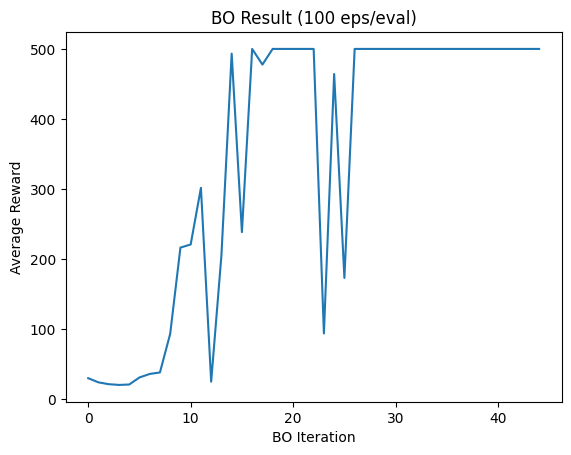

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

BO Optimization Complete. Time: 96.60s | Env Steps: 1572972
Best found PID parameters: P=4.822742655170004, I=0.0, D=19.617712586744165

Plotting Objective Landscape (100 eps/eval)...


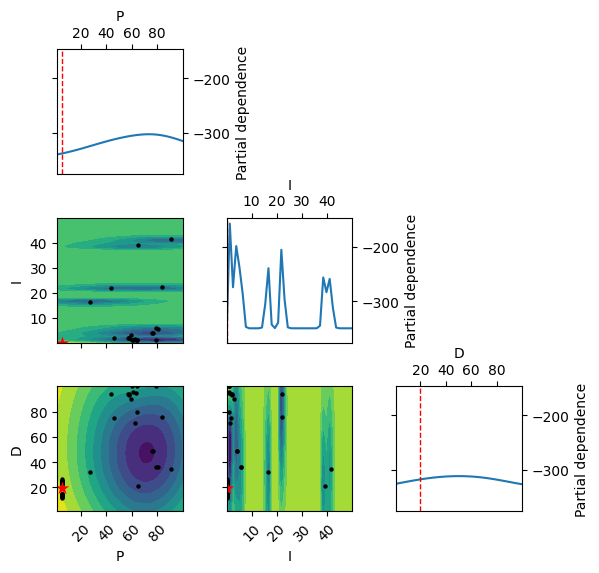


Plotting Evaluations (100 eps/eval)...


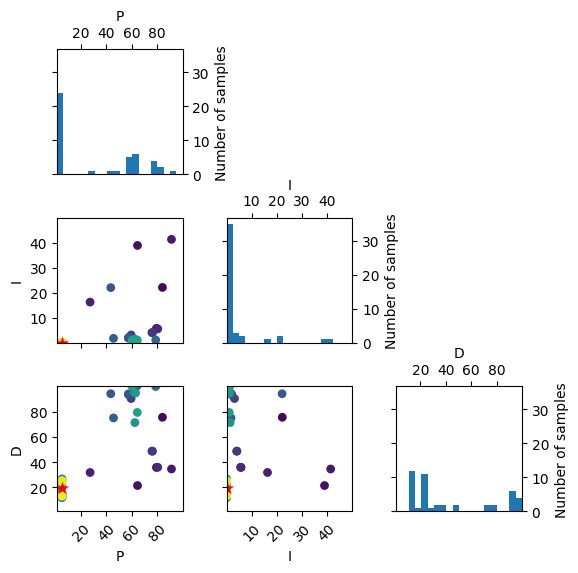

In [ ]:
bo100_env_steps = 0
bo100_scores = []
plt.ion()

def plot_bo100_scores(show_result=False):
    plt.figure(3)
    scores_t = torch.tensor(bo100_scores, dtype=torch.float)
    if show_result:
        plt.title('BO Result (100 eps/eval)')
    else:
        plt.clf()
        plt.title('BO Optimizing (100 eps/eval)...')
    plt.xlabel('BO Iteration')
    plt.ylabel('Average Reward')
    plt.plot(scores_t.numpy())
    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

# =====================================================================
# YOUR CODE HERE: Implement evaluate_agent_for_bo100 (episodes=100)
# Setup your objective wrapper for 100 episodes.
# Run gp_minimize again.
# Assign best_P_100, best_I_100, best_D_100
#
# [REPLACE EVERYTHING FROM HERE DOWN TO THE METRICS TRACKING WITH YOUR CODE]
# =====================================================================

def evaluate_agent_for_bo100(P, I, D, episodes=100):
    global bo100_env_steps
    env = gym.make('CartPole-v1')
    agent = PIDAgent(P, I, D)
    total_reward = 0.0

    for ep in range(episodes):
        state, info = env.reset()
        agent.reset()
        done = False
        ep_reward = 0

        while not done:
            action = agent.act(state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            bo100_env_steps += 1

        total_reward += ep_reward

    env.close()
    avg_score = total_reward / episodes

    bo100_scores.append(avg_score)
    plot_bo100_scores()
    return avg_score

print("Starting BO PID Optimization (100 eps/eval)...")
start_time = time.time()

@use_named_args(space)
def objective_100(P, I, D):
    avg_score = evaluate_agent_for_bo100(P, I, D, episodes=100)
    return -avg_score

res_100 = gp_minimize(
    func=objective_100,
    dimensions=space,
    n_calls=45,
    n_initial_points=5,
)

best_P_100, best_I_100, best_D_100 = res_100.x


# Timing and Metrics (Do not change)
metrics['bo100_time'] = time.time() - start_time
metrics['bo100_steps'] = bo100_env_steps

print('BO Complete')
plot_bo100_scores(show_result=True)
plt.ioff()
plt.show()

best_pid_agent_100 = PIDAgent(P=best_P_100, I=best_I_100, D=best_D_100)
print(f"BO Optimization Complete. Time: {metrics['bo100_time']:.2f}s | Env Steps: {metrics['bo100_steps']}")
print(f"Best found PID parameters: P={best_P_100}, I={best_I_100}, D={best_D_100}")

try:
    print("\nPlotting Objective Landscape (100 eps/eval)...")
    _ = plot_objective(res_100)
    plt.show()
    print("\nPlotting Evaluations (100 eps/eval)...")
    _ = plot_evaluations(res_100)
    plt.show()
except NameError:
    print("Please define res_100 using gp_minimize to see the plots.")

**Interpretacja (45 iteracji BO):**

Podobnie jak przy 10 epizodach, pierwsze 10 iteracji to faza eksploracji
z niskimi wynikami. Później obserwujemy drastyczny wzrost przy ok. 12-13 iteracji. W przeciwieństwie do 10-epizodowej optymalizacji, widzimy jednak pewną stabilizację po ok. 26-27 epizodzie. M. in. dzięki mniejszej wariancji estymatora średniej wartości nagrody. Przy takiej liczbie epizodów optymalizator łatwiej znajduje odpowiednie parametry i może im zaufać, przestać eksplorować.

**Interpretacja (obraz 1):**

**Przekątna** (partial dependence):

**P** - w przeciwieństwie do 10-epizodowej wersji, optymalizator znalazł pewien wpływ P na działanie - niskie P jest nieco lepsze, nie ma już zupełnie płaskiej krzywej.

**I** - krzywa z wieloma skokami wartości, jednak najlepsza przy najniższych wartościach I. Jeśli spojrzymy w histogram z 2. obrazka to widzimy, że tylko pojedyncze próbki znalazły się na wysokich wartościach I - są to małowiarygodne predykcje GP, bo ma za mało danych, aby wiarygodnie modelować w tych rejonach funkcję celu

**D** - lekki spadek przy najniższych wartościach. To odwrotnie niż przy 10 epizodach, gdzie D miało łagodny,
ale widoczny trend. Możliwe, że GP stwierdził, że D powyżej pewnego progu nie ma większego znaczenia.

**P vs I** - widoczne ciemne paski przy konkretnych wartościach I, niezależnie od P, co podkreśla wyniki z przekątnej.

**P vs D** - wyraźne minimum (ciemny fiolet) przy niskim P i średnim D, bardziej skoncentrowane niż przy 10 epizodach

**I vs D** - prawie cała powierzchnia jasna, z wąskimi paskami przy konkertnych wartościach I. D ma minimalny wpływ, wynik zależy prawie wyłącznie od trafienia w odpowiednią wartość I

**Interpretacja (obraz 2):**

**Przekątna:**

**P** - skupienie przy niskich wartościach, tak samo jako przy 10 epizodach

**I** - bardzo mocno skupiony histogram przy niskich wartościach (1-5), optymalizator bardzo szybko ustalił, że niskie I jest optymalne i przestał eksplorować dalej

**D** - skupienie przy niższych wartościach, co jest odmienną sytuacją niż w przypadku 10 epizodów, bo przy większej liczbie epizodów nie jesteśmy aż tak narażeni na szum

**P vs I** - większość kropek skupiona przy I < 5, rozproszone wzdłuż P - optymalizator wie, że I musi być niskie, nie przejmuje się zbytnio P

**P vs D** - skupisko jasnych kropek przy niskim P i niskim D, łatwiejsze do zaobserwowania niż przy 10 epizodach

**I vs D**- próbki skupione przy niskim I, rozrzucone po osi D. Szybkie skoncentrowanie się na niskich wartościach I i swobodniejsza eksploracja D, bo ma ono mniejsze znaczenie


Average Score: 500.0 / 500.0

🏆 SUCCESS! 🏆


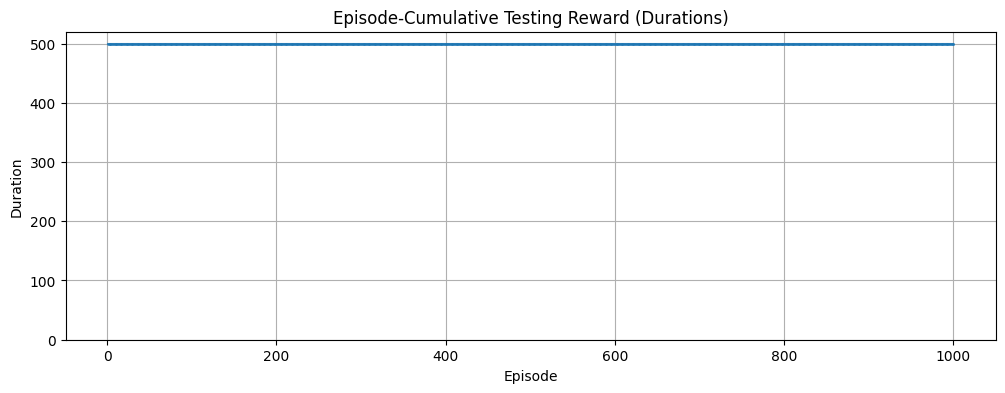

Rendering video to pid_cartpole_100.mp4...


Done rendering.


In [ ]:
def pid_act_100(state):
    return best_pid_agent_100.act(state)

pid100_avg_score = evaluate_policy(pid_act_100, reset_func=best_pid_agent_100.reset, num_eval_episodes=1000)
render_policy_video(pid_act_100, reset_func=best_pid_agent_100.reset, video_path='pid_cartpole_100.mp4')

---
## Final Comparison & Conclusion
Run this final cell to see the proof of concept. The true test of efficiency lies in the **Training / Optimization Phase**.

In [ ]:
print("=" * 60)
print(" FINAL EFFICIENCY COMPARISON ")
print("=" * 60)
all_successful = False
try:
    print("QUALITY EVALUATION SUCCESS CRITERION (1000 Episodes at Max Reward 500):")
    print(f"DQN Evaluated Average:              {dqn_avg_score}/500.0")
    print(f"PID+BO (10 eps) Evaluated Average:  {pid10_avg_score}/500.0")
    print(f"PID+BO (100 eps) Evaluated Average: {pid100_avg_score}/500.0\n")

    if dqn_avg_score == 500.0 and pid10_avg_score == 500.0 and pid100_avg_score == 500.0:
        print("All approaches successfully meet the maximum possible score criterion (confidently")
        print("achieving 500/500 across 1000 episodes).\n")
        all_successful = True
    else:
        print("Warning: One or more approaches did not meet the strict 500/500 success criterion.\n")
except NameError:
    print("Complete all implementations above to see the final comparison.\n")

print("PRIMARY METRIC: TOTAL TRAINING / OPTIMIZATION WALL-CLOCK TIME")
print(f"DQN Training Time:              {metrics['dqn_time']:.2f} seconds")
print(f"PID+BO (10 eps) Training Time:  {metrics['bo10_time']:.2f} seconds")
print(f"PID+BO (100 eps) Training Time: {metrics['bo100_time']:.2f} seconds")

time_factor = metrics['dqn_time'] / metrics['bo100_time'] if metrics['bo100_time'] > 0 else float('inf')
print(f"-> Even with the smoother (slower) BO objective, PID+BO is {time_factor:.1f}x faster in wall-clock training time.\n")

print(f"DQN Env Interactions:              {metrics['dqn_steps']} steps")
print(f"PID+BO (10 eps) Env Interactions:  {metrics['bo10_steps']} steps")
print(f"PID+BO (100 eps) Env Interactions: {metrics['bo100_steps']} steps\n")

if all_successful:
    print("Conclusion: By injecting a structural heuristic (classical PID equations), we collapse the")
    print("vast neural search space into a 3-variable system (P, I, D). Bayesian ")
    print("Optimization navigates this classical space exponentially faster than gradient descent ")
    print("navigates a neural network's weights, completely bypassing the need for thousands of ")
    print("backpropagation steps during training. Furthermore, testing variations like 100 episodes-per-eval")
    print("proves that we can trade computation time for optimization stability (smoothness).")
else:
    print("Conclusion: The optimization did not fully converge to the maximum score. Adjust your parameters,")
    print("verify your environment logic, or run the Bayesian Optimization for more iterations to find a")
    print("perfectly stable PID configuration before comparing the final efficiencies.")
print("=" * 60)

 FINAL EFFICIENCY COMPARISON 
QUALITY EVALUATION SUCCESS CRITERION (1000 Episodes at Max Reward 500):
DQN Evaluated Average:              500.0/500.0
PID+BO (10 eps) Evaluated Average:  500.0/500.0
PID+BO (100 eps) Evaluated Average: 500.0/500.0

All approaches successfully meet the maximum possible score criterion (confidently
achieving 500/500 across 1000 episodes).

PRIMARY METRIC: TOTAL TRAINING / OPTIMIZATION WALL-CLOCK TIME
DQN Training Time:              701.65 seconds
PID+BO (10 eps) Training Time:  35.14 seconds
PID+BO (100 eps) Training Time: 96.60 seconds
-> Even with the smoother (slower) BO objective, PID+BO is 7.3x faster in wall-clock training time.

DQN Env Interactions:              118169 steps
PID+BO (10 eps) Env Interactions:  74130 steps
PID+BO (100 eps) Env Interactions: 1572972 steps

Conclusion: By injecting a structural heuristic (classical PID equations), we collapse the
vast neural search space into a 3-variable system (P, I, D). Bayesian 
Optimization naviga

In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.52.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.9.0.47.45
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cf